# LOADING IN PACKAGES AND DATA

In [549]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn.metrics as skm
import statsmodels.api as sm
from functools import reduce
from scipy.optimize import minimize
from scipy.special import factorial
from scipy.stats import norm
from scipy.integrate import simpson
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, RepeatedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, silhouette_score, ConfusionMatrixDisplay, roc_auc_score
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier as dec_tr, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier as rnd_frst, AdaBoostRegressor, AdaBoostClassifier as ada_boost
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from kneed import KneeLocator
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from scipy.stats import t

In [550]:
EVI_df = pd.read_csv('PltEVI.csv', names=['Year', 'EVI'])

In [551]:
height_df = pd.read_csv('PltHeight.csv', names=['Year', 'Height'])

In [552]:
HSUS_df = pd.read_csv('PltHSUS.csv', names=['Year', 'Pct of Total Wealth'])

In [553]:
immigration_df = pd.read_csv('PltImmigration.csv', names=['Year', 'Pct Foreign Born'])

In [554]:
life_expectancy_df = pd.read_csv('PltLifeExpectancy.csv', names=['Year','Life Expectancy'])

In [555]:
polarization_df = pd.read_csv('PltPolarization.csv', names=['Year','Polarization'])

In [556]:
wage_gdp_ratio_df = pd.read_csv('PltWageGDPRatio.csv', names=['Year', 'Wage-GDP Ratio'])

In [557]:
USPV_df = pd.read_excel('USPVdatabase.xlsx')

## ---------------------------------------------------------------------------------------------------------

# 1. WRANGLE DATA

## EVI DATA

In [558]:
#Interpolating the data in the EVI df
EVI_df = EVI_df.sort_values(by='Year')
EVI_target_years_list = np.arange(1791,2010,1)
EVI_target_years = np.array(EVI_target_years_list)
EVI_interpolation_model = interp1d(EVI_df['Year'], EVI_df['EVI'], kind='linear')
interpolated_EVI = EVI_interpolation_model(EVI_target_years)
interpolated_EVI_data = {
    'Year': EVI_target_years, 
    'Interpolated EVI': interpolated_EVI
}
interpolated_EVI_df = pd.DataFrame(interpolated_EVI_data)
interpolated_EVI_df

,Year,Interpolated EVI
0,1791,25.820309
1,1792,26.577426
2,1793,27.398681
3,1794,28.286866
4,1795,29.191289
...,...,...
214,2005,964.700749
215,2006,986.435333
216,2007,999.011458
217,2008,1011.702951


## HEIGHT DATA

In [559]:
#Interpolating the data in the Height df
height_df = height_df.sort_values(by='Year')
height_target_years_list = np.arange(1741,1970,1)
height_target_years = np.array(height_target_years_list)
height_interpolation_model = interp1d(height_df['Year'], height_df['Height'], kind='linear')
interpolated_height = height_interpolation_model(height_target_years)
interpolated_height_data = {
    'Year': height_target_years, 
    'Interpolated Height': interpolated_height
}
interpolated_height_df = pd.DataFrame(interpolated_height_data)
interpolated_height_df

,Year,Interpolated Height
0,1741,172.105612
1,1742,172.111353
2,1743,172.122252
3,1744,172.132016
4,1745,172.141001
...,...,...
224,1965,177.325960
225,1966,177.314474
226,1967,177.327947
227,1968,177.348755


## HSUS DATA

In [560]:
#Interpolating the data in the HSUS df
HSUS_df = HSUS_df.sort_values(by='Year')
HSUS_target_years_list = np.arange(1791,1999,1)
HSUS_target_years = np.array(HSUS_target_years_list)
HSUS_interpolation_model = interp1d(HSUS_df['Year'], HSUS_df['Pct of Total Wealth'], kind='linear')
interpolated_HSUS = HSUS_interpolation_model(HSUS_target_years)
interpolated_HSUS_data = {
    'Year': HSUS_target_years, 
    'Interpolated Pct of Total Wealth': interpolated_HSUS
}
interpolated_HSUS_df = pd.DataFrame(interpolated_HSUS_data)
interpolated_HSUS_df

,Year,Interpolated Pct of Total Wealth
0,1791,17.822617
1,1792,17.912625
2,1793,17.996741
3,1794,18.074654
4,1795,18.164692
...,...,...
203,1994,38.094455
204,1995,38.384919
205,1996,38.354905
206,1997,38.218093


## IMMIGRATION DATA

In [561]:
#Interpolating the data in the Immigration df
immigration_df = immigration_df.sort_values(by='Year')
immigration_target_years_list = np.arange(1816,2005,1)
immigration_target_years = np.array(immigration_target_years_list)
immigration_interpolation_model = interp1d(immigration_df['Year'], immigration_df['Pct Foreign Born'], kind='linear')
interpolated_immigration = immigration_interpolation_model(immigration_target_years)
interpolated_immigration_data = {
    'Year': immigration_target_years, 
    'Interpolated Pct Foreign Born': interpolated_immigration
}
interpolated_immigration_df = pd.DataFrame(interpolated_immigration_data)
interpolated_immigration_df

,Year,Interpolated Pct Foreign Born
0,1816,1.407356
1,1817,1.421632
2,1818,1.434328
3,1819,1.448620
4,1820,1.461506
...,...,...
184,2000,10.641425
185,2001,10.898899
186,2002,11.175595
187,2003,11.454322


## LIFE EXPECTANCY DATA

In [562]:
#Interpolating the data in the Life Expectancy df
life_expectancy_df = life_expectancy_df.sort_values(by='Year')
life_expectancy_target_years_list = np.arange(1741,1970,1)
life_expectancy_target_years = np.array(life_expectancy_target_years_list)
life_expectancy_interpolation_model = interp1d(life_expectancy_df['Year'], life_expectancy_df['Life Expectancy'], kind='linear')
interpolated_life_expectancy = life_expectancy_interpolation_model(life_expectancy_target_years)
interpolated_life_expectancy_data = {
    'Year': life_expectancy_target_years, 
    'Interpolated Life Expectancy': interpolated_life_expectancy
}
interpolated_life_expectancy_df = pd.DataFrame(interpolated_life_expectancy_data)
interpolated_life_expectancy_df

,Year,Interpolated Life Expectancy
0,1741,52.163257
1,1742,52.223999
2,1743,52.291326
3,1744,52.351058
4,1745,52.391912
...,...,...
224,1965,59.402995
225,1966,59.425350
226,1967,59.449157
227,1968,59.467389


## POLARIZATION DATA

In [563]:
#Interpolating the data in the Polarization df
polarization_df = polarization_df.sort_values(by='Year')
polarization_target_years_list = np.arange(1791,2010,1)
polarization_target_years = np.array(polarization_target_years_list)
polarization_interpolation_model = interp1d(polarization_df['Year'], polarization_df['Polarization'], kind='linear')
interpolated_polarization = polarization_interpolation_model(polarization_target_years)
interpolated_polarization_data = {
    'Year': polarization_target_years, 
    'Interpolated Polarization': interpolated_polarization
}
interpolated_polarization_df = pd.DataFrame(interpolated_polarization_data)
interpolated_polarization_df

,Year,Interpolated Polarization
0,1791,0.531109
1,1792,0.536623
2,1793,0.554502
3,1794,0.576272
4,1795,0.598345
...,...,...
214,2005,0.930541
215,2006,0.946739
216,2007,0.955930
217,2008,0.962317


## WAGE - GDP RATIO DATA

In [564]:
#Interpolating the data in the Life Expectancy df
wage_gdp_ratio_df = wage_gdp_ratio_df.sort_values(by='Year')
wage_gdp_ratio_target_years_list = np.arange(1791,2010,1)
wage_gdp_ratio_target_years = np.array(wage_gdp_ratio_target_years_list)
wage_gdp_ratio_interpolation_model = interp1d(wage_gdp_ratio_df['Year'], wage_gdp_ratio_df['Wage-GDP Ratio'], kind='linear')
interpolated_wage_gdp_ratio = wage_gdp_ratio_interpolation_model(wage_gdp_ratio_target_years)
interpolated_wage_gdp_ratio_data = {
    'Year': wage_gdp_ratio_target_years, 
    'Interpolated Wage-GDP Ratio': interpolated_wage_gdp_ratio
}
interpolated_wage_gdp_ratio_df = pd.DataFrame(interpolated_wage_gdp_ratio_data)
interpolated_wage_gdp_ratio_df

,Year,Interpolated Wage-GDP Ratio
0,1791,1.173255
1,1792,1.110455
2,1793,1.126398
3,1794,0.899204
4,1795,1.021260
...,...,...
214,2005,0.472191
215,2006,0.462834
216,2007,0.456065
217,2008,0.456813


## POPULATION DATA

In [565]:
#Load data from given website and interpolate
data = {
    'Year': [
        1610, 1620, 1630, 1640, 1650, 1660, 1670, 1680, 1690, 1700,
        1710, 1720, 1730, 1740, 1750, 1760, 1770, 1780, 1790, 1800,
        1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900,
        1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010
    ],
    'Population': [
        350, 2302, 4646, 26634, 50368, 75058, 111935, 151507, 210372, 250888,
        331711, 466185, 629445, 905563, 1170760, 1593625, 2148076, 2780369, 3929214, 5308483,
        7239881, 9638453, 12866020, 17069453, 23191876, 31443321, 38558371, 50189209, 62979766, 76212168,
        92228496, 106021537, 123202624, 132164569, 151325798, 179323175, 203211926, 226656805, 248709873, 281421906, 308745538
    ]
}
population_df = pd.DataFrame(data)
population_target_years_list = np.arange(1610,2011,1)
population_target_years = np.array(population_target_years_list)
population_interpolation_model = interp1d(population_df['Year'], population_df['Population'], kind='linear')
interpolated_population = population_interpolation_model(population_target_years)
interpolated_population_data = {
    'Year': population_target_years, 
    'Interpolated Population': interpolated_population
}
interpolated_population_df = pd.DataFrame(interpolated_population_data)
interpolated_population_df

,Year,Interpolated Population
0,1610,350.0
1,1611,545.2
2,1612,740.4
3,1613,935.6
4,1614,1130.8
...,...,...
396,2006,297816085.2
397,2007,300548448.4
398,2008,303280811.6
399,2009,306013174.8


## USPV DATA

In [566]:
#count missing values per row and sort to keep duplicate rows with the fewest missing values and drop others
USPV_df['missing_count'] = USPV_df.isnull().sum(axis=1)
USPV_df = USPV_df.sort_values(by=['missing_count'], ascending=True)
USPV_df = USPV_df.drop_duplicates(subset=['description'], keep='first')
USPV_df.drop('missing_count', axis=1, inplace=True)

#remove decimal part of each year for summing purposes later 
USPV_df = USPV_df.sort_values(by=['year'], ascending=True)
USPV_df['Year'] = np.trunc(USPV_df['year'])
USPV_df.drop('year', axis=1, inplace=True)

#make a new df with only fatalities and year
USPV_fatalities_df = pd.DataFrame({
    'Year': USPV_df['Year'],
    'Fatalities': USPV_df['fatalities']})
USPV_fatalities_df['Fatalities'] = pd.to_numeric(USPV_fatalities_df['Fatalities'], errors='coerce')
USPV_fatalities_df.dropna(inplace=True)

#groupby year and sum fatalities 
USPV_summed_df = pd.DataFrame(USPV_fatalities_df.groupby('Year')['Fatalities'].sum())
USPV_summed_df.reset_index(inplace=True)

#interpolate for years with fatalities of 0
USPV_target_years_list = np.arange(1782,2011,1)
USPV_target_years = np.array(USPV_target_years_list)
USPV_interpolation_model = interp1d(USPV_summed_df['Year'], USPV_summed_df['Fatalities'], kind='linear')
interpolated_fatalities = USPV_interpolation_model(USPV_target_years_list)
interpolated_fatalities_data = {
    'Year': USPV_target_years, 
    'Interpolated Fatalities': interpolated_fatalities
}
interpolated_fatalities_df = pd.DataFrame(interpolated_fatalities_data)
interpolated_fatalities_df

,Year,Interpolated Fatalities
0,1782,1.000000
1,1783,5.000000
2,1784,9.000000
3,1785,12.666667
4,1786,16.333333
...,...,...
224,2006,23.000000
225,2007,28.000000
226,2008,62.000000
227,2009,120.000000


## COMBINE DATAFRAMES

In [567]:
#Combine df
dfs = [interpolated_EVI_df, 
       interpolated_height_df,
       interpolated_HSUS_df,
       interpolated_immigration_df,
       interpolated_life_expectancy_df,
       interpolated_wage_gdp_ratio_df,
       interpolated_polarization_df,
       interpolated_population_df, 
       interpolated_fatalities_df]
df_final = reduce(lambda left, right: pd.merge(left, right, on='Year', how='outer'), dfs)
df_final = df_final.sort_values(by='Year')
df_final

,Year,Interpolated EVI,Interpolated Height,Interpolated Pct of Total Wealth,Interpolated Pct Foreign Born,Interpolated Life Expectancy,Interpolated Wage-GDP Ratio,Interpolated Polarization,Interpolated Population,Interpolated Fatalities
269,1610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,350.0,NaN
270,1611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,545.2,NaN
271,1612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,740.4,NaN
272,1613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,935.6,NaN
273,1614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1130.8,NaN
...,...,...,...,...,...,...,...,...,...,...
215,2006,986.435333,NaN,NaN,NaN,NaN,0.462834,0.946739,297816085.2,23.0
216,2007,999.011458,NaN,NaN,NaN,NaN,0.456065,0.955930,300548448.4,28.0
217,2008,1011.702951,NaN,NaN,NaN,NaN,0.456813,0.962317,303280811.6,62.0
218,2009,1026.299724,NaN,NaN,NaN,NaN,0.452469,0.969531,306013174.8,120.0


## CREATE POLITICAL INSTABILITY VARIABLE

In [568]:
#Combine df
df_final['Moving Avg Population'] = df_final['Interpolated Population'].rolling(window=5, center=True).mean()
df_final['Moving Avg Fatalities'] = df_final['Interpolated Fatalities'].rolling(window=5, center=True).mean()
df_final['Political Instability Index'] = np.log(df_final['Moving Avg Fatalities']/df_final['Moving Avg Population']*1000000)
df_final = df_final.dropna()
df_final

,Year,Interpolated EVI,Interpolated Height,Interpolated Pct of Total Wealth,Interpolated Pct Foreign Born,Interpolated Life Expectancy,Interpolated Wage-GDP Ratio,Interpolated Polarization,Interpolated Population,Interpolated Fatalities,Moving Avg Population,Moving Avg Fatalities,Political Instability Index
25,1816,42.974108,172.929055,19.879433,1.407356,52.221900,1.546509,0.619734,8679024.2,1.000000,8.679024e+06,1.000000,-2.160909
26,1817,43.467547,172.918156,19.926103,1.421632,52.081696,1.471497,0.530621,8918881.4,1.000000,8.918881e+06,1.000000,-2.188171
27,1818,43.994704,172.909647,19.997140,1.434328,51.972450,1.246877,0.419006,9158738.6,1.000000,9.158739e+06,1.066667,-2.150170
28,1819,44.500525,172.905570,20.069607,1.448620,51.869344,1.319066,0.227962,9398595.8,1.000000,9.415176e+06,1.200000,-2.060001
29,1820,44.979429,172.910524,20.137499,1.461506,51.769738,1.303405,0.199464,9638453.0,1.333333,9.688193e+06,1.400000,-1.934436
...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,1965,166.328253,177.325960,34.887826,5.040060,59.402995,0.821822,0.478753,191267550.5,79.000000,1.912676e+08,75.800000,-0.925575
175,1966,160.631380,177.314474,35.583792,4.972200,59.425350,0.798166,0.478430,193656425.6,43.000000,1.936564e+08,90.400000,-0.761841
176,1967,155.233650,177.327947,36.169940,4.904236,59.449157,0.795888,0.473767,196045300.7,180.000000,1.960453e+08,82.800000,-0.861918
177,1968,150.018717,177.348755,37.031897,4.834416,59.467389,0.783966,0.470784,198434175.8,84.000000,1.984342e+08,72.400000,-1.008251


## FILTER FOR 1901 to 1910

In [569]:
#Filter from 1901 to 1910
filtered_df = df_final[(df_final['Year'] >= 1901) & (df_final['Year'] <= 1910)]
filtered_df

,Year,Interpolated EVI,Interpolated Height,Interpolated Pct of Total Wealth,Interpolated Pct Foreign Born,Interpolated Life Expectancy,Interpolated Wage-GDP Ratio,Interpolated Polarization,Interpolated Population,Interpolated Fatalities,Moving Avg Population,Moving Avg Fatalities,Political Instability Index
110,1901,1431.767293,170.197938,30.675407,13.729301,50.337171,0.660217,0.838324,77813800.8,18.0,77869479.32,26.6,-1.074123
111,1902,1510.545309,170.405500,31.169583,13.841174,50.496450,0.646215,0.854462,79415433.6,8.0,79415433.60,27.4,-1.064150
112,1903,1601.398601,170.616942,31.494710,13.950312,50.646317,0.639819,0.865043,81017066.4,29.0,81017066.40,18.2,-1.493238
113,1904,1689.293040,170.831051,31.906419,14.059731,50.804081,0.643444,0.873797,82618699.2,27.0,82618699.20,27.6,-1.096420
114,1905,1785.527690,171.045075,32.516822,14.171413,50.973398,0.610180,0.885079,84220332.0,9.0,84220332.00,28.6,-1.080030
115,1906,1894.631257,171.248898,32.878133,14.279780,51.129860,0.605774,0.895889,85821964.8,65.0,85821964.80,31.0,-1.018288
116,1907,2002.625204,171.453918,33.170509,14.390483,51.272543,0.589764,0.894736,87423597.6,13.0,87423597.60,29.8,-1.076257
117,1908,2111.800703,171.669248,33.733500,14.501008,51.422181,0.608356,0.886462,89025230.4,41.0,89025230.40,45.0,-0.682257
118,1909,2240.490792,171.884022,34.318609,14.606939,51.579495,0.609628,0.878413,90626863.2,21.0,90582397.46,37.0,-0.895342
119,1910,2363.779067,172.090472,34.667144,14.650722,51.739812,0.612487,0.869743,92228496.0,85.0,92095098.78,44.6,-0.725088


# 2. EXPLORATORY DATA ANALYSIS

In [570]:
#Function to plot line graphs
def plot_line_graph(df1, df2):
    x1 = df1.iloc[:, 0]
    y1 = df1.iloc[:, 1]
    x2 = df2.iloc[:, 0]
    y2 = df2.iloc[:, 1]
    plt.figure(figsize=(10, 5))
    plt.plot(x1, y1, marker='o', linestyle='-', markersize=2, linewidth=1, color='b', label=df1.columns[1])
    plt.plot(x2, y2, marker='o', linestyle='-', markersize=2, linewidth=1, color='r', label=df2.columns[1])
    plt.title(f'Line Graph of {df2.columns[1]} vs {df2.columns[0]}')
    plt.xlabel(df2.columns[0])  
    plt.ylabel(df2.columns[1])
    plt.legend()
    plt.show()

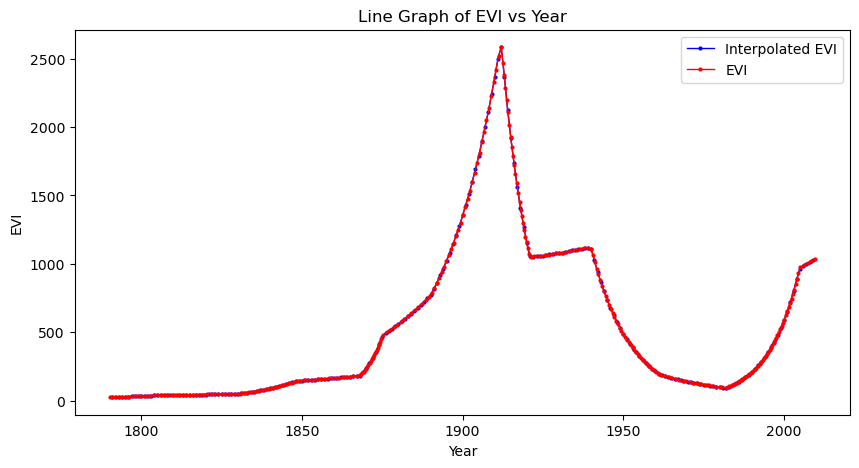

In [571]:
plot_line_graph(interpolated_EVI_df, EVI_df)

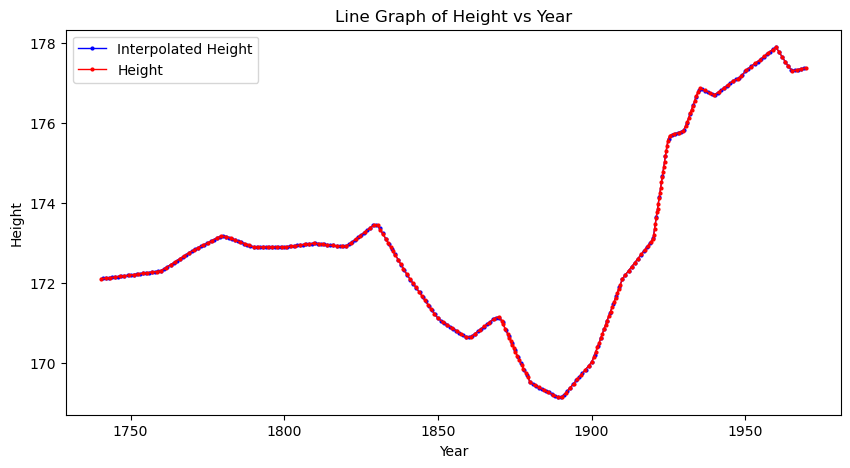

In [572]:
plot_line_graph(interpolated_height_df, height_df)

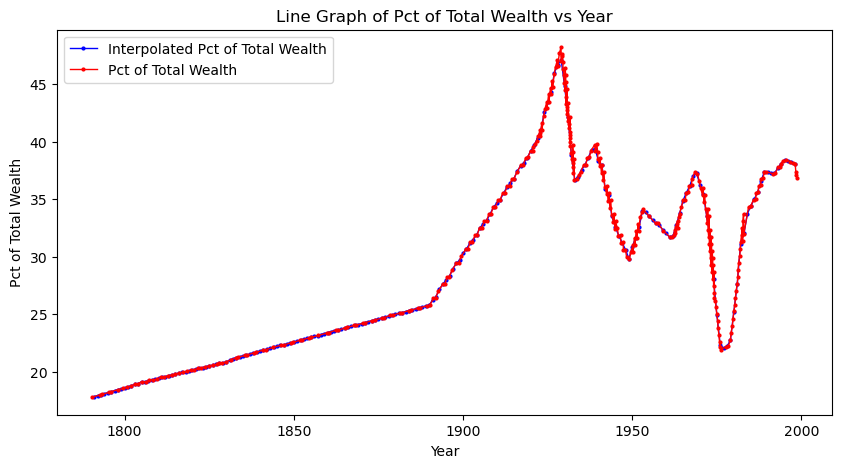

In [573]:
plot_line_graph(interpolated_HSUS_df, HSUS_df)

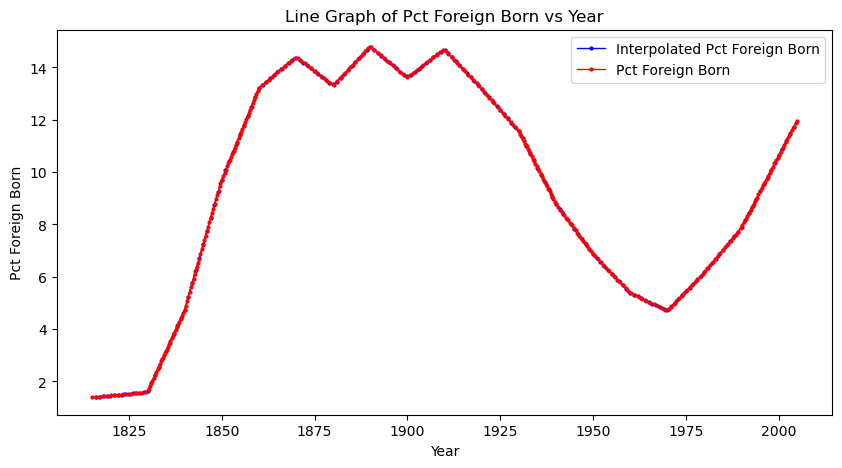

In [574]:
plot_line_graph(interpolated_immigration_df, immigration_df)

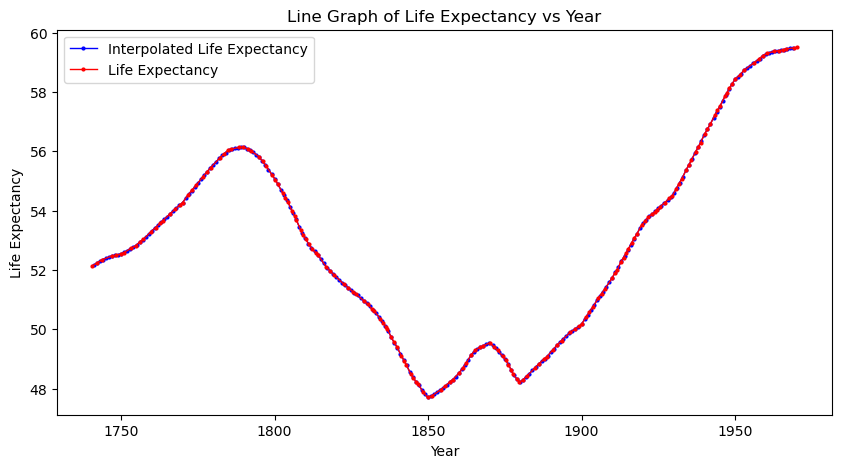

In [575]:
plot_line_graph(interpolated_life_expectancy_df, life_expectancy_df)

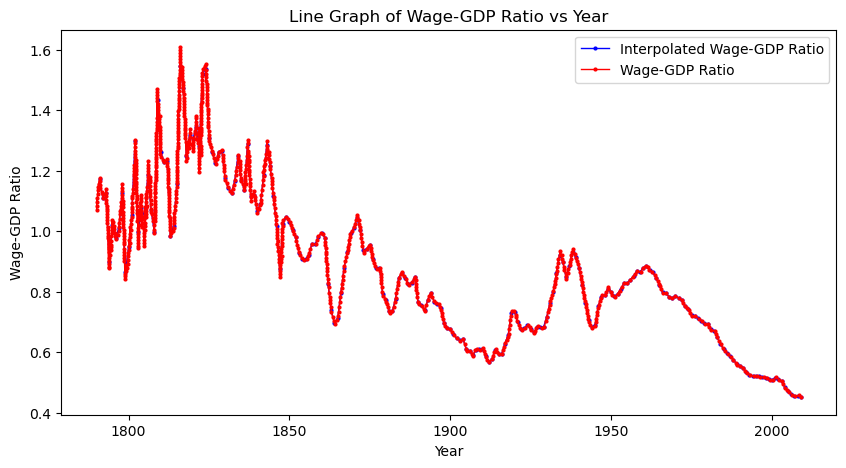

In [576]:
plot_line_graph(interpolated_wage_gdp_ratio_df, wage_gdp_ratio_df)

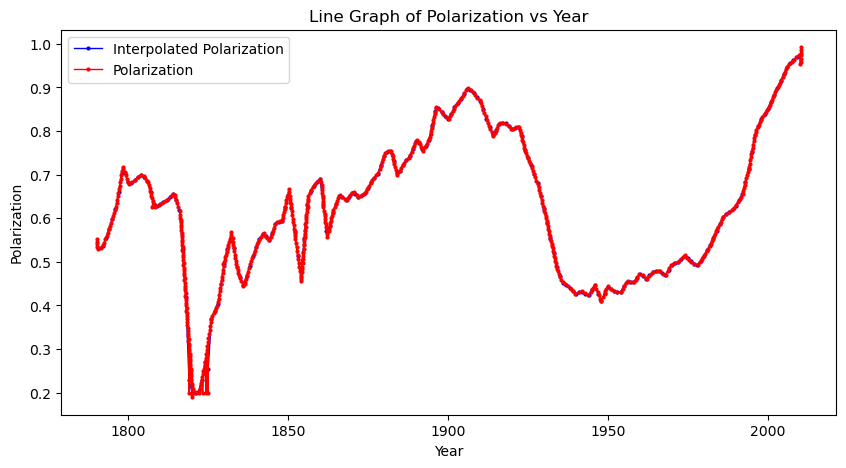

In [577]:
plot_line_graph(interpolated_polarization_df, polarization_df)

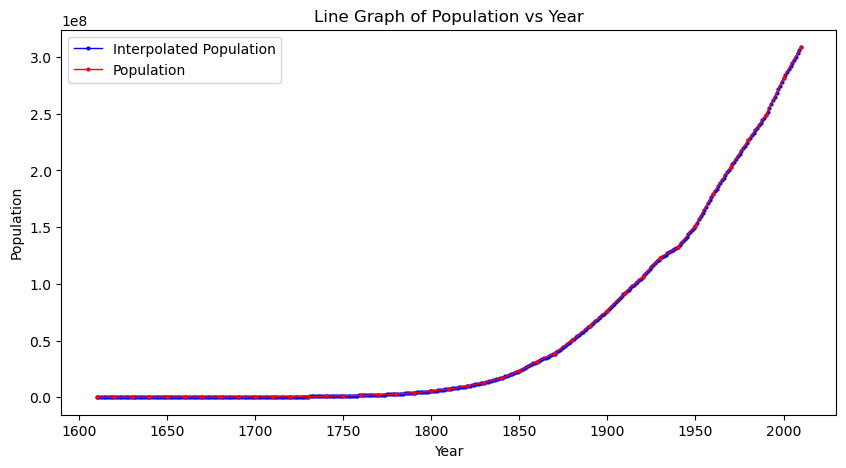

In [578]:
plot_line_graph(interpolated_population_df, population_df)

In [609]:
df_final['Political Instability Index'].describe()

count    154.000000
mean      -0.563339
std        1.435153
min       -3.341105
25%       -1.630994
50%       -0.310002
75%        0.175002
max        2.670709
Name: Political Instability Index, dtype: float64

Text(-0.563338567035209, 22, 'Mean Political Instability Index ----- ')

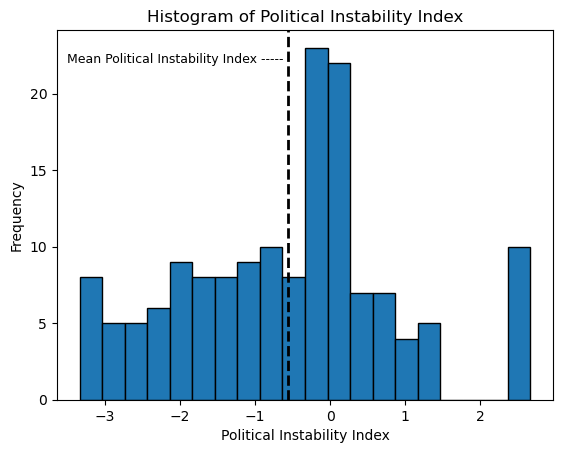

In [579]:
#Plot
plt.hist(df_final['Political Instability Index'], bins=20, edgecolor='black')
plt.title('Histogram of Political Instability Index')
plt.xlabel('Political Instability Index')
plt.ylabel('Frequency')
plt.axvline(x=np.nanmean(df_final['Political Instability Index']), color='black', linestyle='--',linewidth=2)
plt.text(np.nanmean(df_final['Political Instability Index']), 22, 'Mean Political Instability Index ----- ', rotation=0, horizontalalignment='right', color='black', fontsize=9)

Text(0, 0.5, 'Political Instability Index')

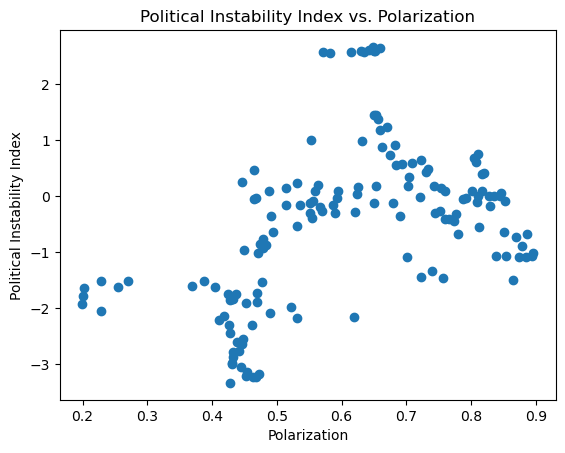

In [580]:
#Plot
plt.scatter(df_final['Interpolated Polarization'], df_final['Political Instability Index'])
plt.title('Political Instability Index vs. Polarization')
plt.xlabel('Polarization')
plt.ylabel('Political Instability Index')

Text(0, 0.5, 'Political Instability Index')

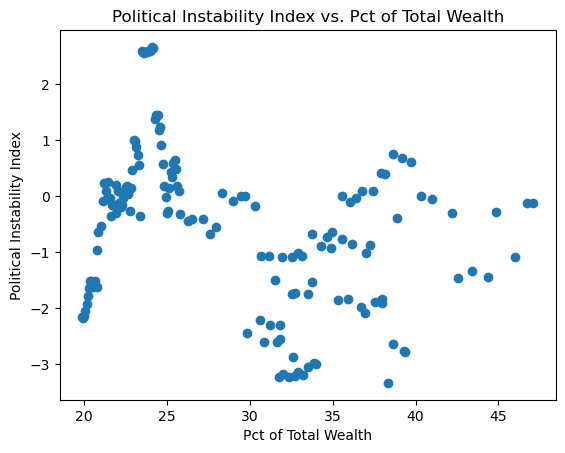

In [581]:
#Plot
plt.scatter(df_final['Interpolated Pct of Total Wealth'], df_final['Political Instability Index'])
plt.title('Political Instability Index vs. Pct of Total Wealth')
plt.xlabel('Pct of Total Wealth')
plt.ylabel('Political Instability Index')

Text(0, 0.5, 'Political Instability Index')

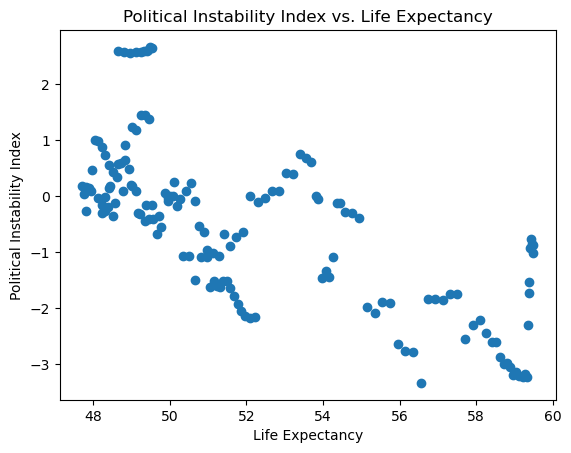

In [582]:
#Plot
plt.scatter(df_final['Interpolated Life Expectancy'], df_final['Political Instability Index'])
plt.title('Political Instability Index vs. Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Political Instability Index')

Text(0, 0.5, 'Political Instability Index')

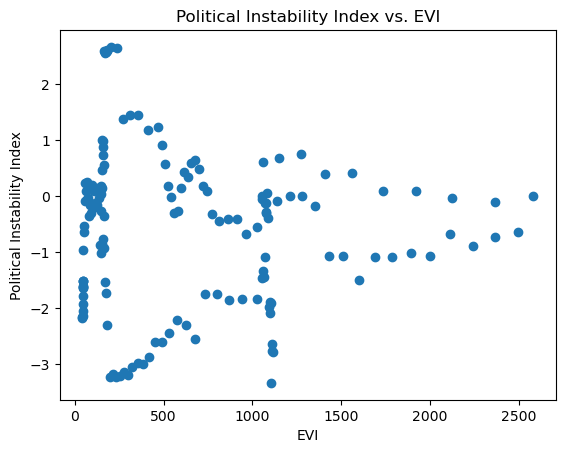

In [583]:
#Plot
plt.scatter(df_final['Interpolated EVI'], df_final['Political Instability Index'])
plt.title('Political Instability Index vs. EVI')
plt.xlabel('EVI')
plt.ylabel('Political Instability Index')

# 3. FIND THE BEST REGRESSOR

## Split Model

In [584]:
X = df_final.iloc[:, 1:8]
y = df_final.iloc[:, -1:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

## Linear Regression

In [585]:
#Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Create linear regression
linear_model = LinearRegression(fit_intercept=True)
linear_model.fit(X_train_scaled, y_train)
print('Coefficients:', linear_model.coef_)
print('Intercept:', linear_model.intercept_)

#Evaluate model on test data
y_pred = linear_model.predict(X_test_scaled)
linear_test_mse = mean_squared_error(y_test, y_pred)
linear_test_mae = mean_absolute_error(y_test, y_pred)
linear_test_rsquared = r2_score(y_test, y_pred)
print('Test Mean Squared Error (MSE):', linear_test_mse)
print('Test Mean Absolute Error (MAE):', linear_test_mae)
print('Test R-squared (R²) Score:', linear_test_rsquared)

Coefficients: [[-0.79885849  0.28283206  0.11556598  0.55956358 -1.08179282 -0.35613956
   0.18560867]]
Intercept: [-0.52587488]
Test Mean Squared Error (MSE): 0.5808323793869066
Test Mean Absolute Error (MAE): 0.6425036290693065
Test R-squared (R²) Score: 0.6374257674158176


## Lasso Regression

In [586]:
#Set up lasso regression and find best parameters
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(fit_intercept=True))
])

lasso_param_grid = {
    'lasso__alpha': np.logspace(-4, 4, 1000)
}

lasso_grid_search = GridSearchCV(estimator=lasso_pipeline, param_grid=lasso_param_grid, cv=10, scoring='neg_mean_squared_error', verbose=1)
lasso_grid_search.fit(X_train, y_train)

#Best parameters and MSE
best_lasso = lasso_grid_search.best_estimator_.named_steps['lasso']
lasso_best_alpha = lasso_grid_search.best_params_['lasso__alpha']
lasso_best_mse = -lasso_grid_search.best_score_
print('Best alpha:', lasso_best_alpha)
print('Best Train Mean Squared Error (MSE):', lasso_best_mse)
print('Coefficients:', best_lasso.coef_)
print('Intercept:', best_lasso.intercept_)

#Evaluate model on test data
y_pred = lasso_grid_search.predict(X_test)
lasso_test_mse = mean_squared_error(y_test, y_pred)
lasso_test_mae = mean_absolute_error(y_test, y_pred)
lasso_test_rsquared = r2_score(y_test, y_pred)
print('Test Mean Squared Error (MSE):', lasso_test_mse)
print('Test Mean Absolute Error (MAE):', lasso_test_mae)
print('Test R-squared (R²) Score:', lasso_test_rsquared)

Fitting 10 folds for each of 1000 candidates, totalling 10000 fits
Best alpha: 0.028738126918510663
Best Train Mean Squared Error (MSE): 0.8122659814144642
Coefficients: [-0.64377204 -0.          0.          0.63858607 -0.70544681 -0.2246095
  0.09848802]
Intercept: [-0.52587488]
Test Mean Squared Error (MSE): 0.5826168065749505
Test Mean Absolute Error (MAE): 0.6600221829087624
Test R-squared (R²) Score: 0.6363118706337714


## Ridge Regression

In [587]:
#Set up ridge regression and find best parameters
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(fit_intercept=True))
])

ridge_param_grid = {
    'ridge__alpha': np.logspace(-4, 4, 1000)
}

ridge_grid_search = GridSearchCV(estimator=ridge_pipeline, param_grid=ridge_param_grid, cv=10, scoring='neg_mean_squared_error', verbose=1)
ridge_grid_search.fit(X_train, y_train)

#Best parameters and MSE
best_ridge = ridge_grid_search.best_estimator_.named_steps['ridge']
ridge_best_alpha = ridge_grid_search.best_params_['ridge__alpha']
ridge_best_mse = -ridge_grid_search.best_score_
print('Best alpha:', ridge_best_alpha)
print('Best Train Mean Squared Error (MSE):', ridge_best_mse)
print('Coefficients:', best_ridge.coef_)
print('Intercept:', best_ridge.intercept_)

#Evaluate model on test data
y_pred = ridge_grid_search.predict(X_test)
ridge_test_mse = mean_squared_error(y_test, y_pred)
ridge_test_mae = mean_absolute_error(y_test, y_pred)
ridge_test_rsquared = r2_score(y_test, y_pred)
print('Test Mean Squared Error (MSE):', ridge_test_mse)
print('Test Mean Absolute Error (MAE):', ridge_test_mae)
print('Test R-squared (R²) Score:', ridge_test_rsquared)

Fitting 10 folds for each of 1000 candidates, totalling 10000 fits
Best alpha: 3.8778284145894535
Best Train Mean Squared Error (MSE): 0.8065090609217357
Coefficients: [[-0.72031004 -0.02955446  0.0827778   0.54834497 -0.74943765 -0.28301347
   0.15335507]]
Intercept: [-0.52587488]
Test Mean Squared Error (MSE): 0.5829338750506541
Test Mean Absolute Error (MAE): 0.6553255597588694
Test R-squared (R²) Score: 0.6361139463042492


## Decision Tree Regressor

In [588]:
#Set up decision tree regressor and find best parameters
tree_model = DecisionTreeRegressor(random_state=42)

tree_param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 35, 40],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
}

tree_grid_search = GridSearchCV(estimator=tree_model, param_grid=tree_param_grid, cv=10, scoring='neg_mean_squared_error', verbose=1)
tree_grid_search.fit(X_train, y_train)

#Best parameters and MSE
tree_best_params = tree_grid_search.best_params_
tree_best_mse = -tree_grid_search.best_score_
print('Best Parameters:', tree_best_params)
print('Best Train Mean Squared Error (MSE):', tree_best_mse)

#Evaluate model on test data
best_tree = DecisionTreeRegressor(**tree_best_params, random_state=42)
best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)
tree_test_mse = mean_squared_error(y_test, y_pred)
tree_test_mae = mean_absolute_error(y_test, y_pred)
tree_test_rsquared = r2_score(y_test, y_pred)
print('Test Mean Squared Error (MSE):', tree_test_mse)
print('Test Mean Absolute Error (MAE):', tree_test_mae)
print('Test R-squared (R²) Score:', tree_test_rsquared)

Fitting 10 folds for each of 63 candidates, totalling 630 fits
Best Parameters: {'ccp_alpha': 0.0, 'max_depth': 5}
Best Train Mean Squared Error (MSE): 0.28429671860149897
Test Mean Squared Error (MSE): 0.3902998885917978
Test Mean Absolute Error (MAE): 0.4160218285499258
Test R-squared (R²) Score: 0.7563622697253283


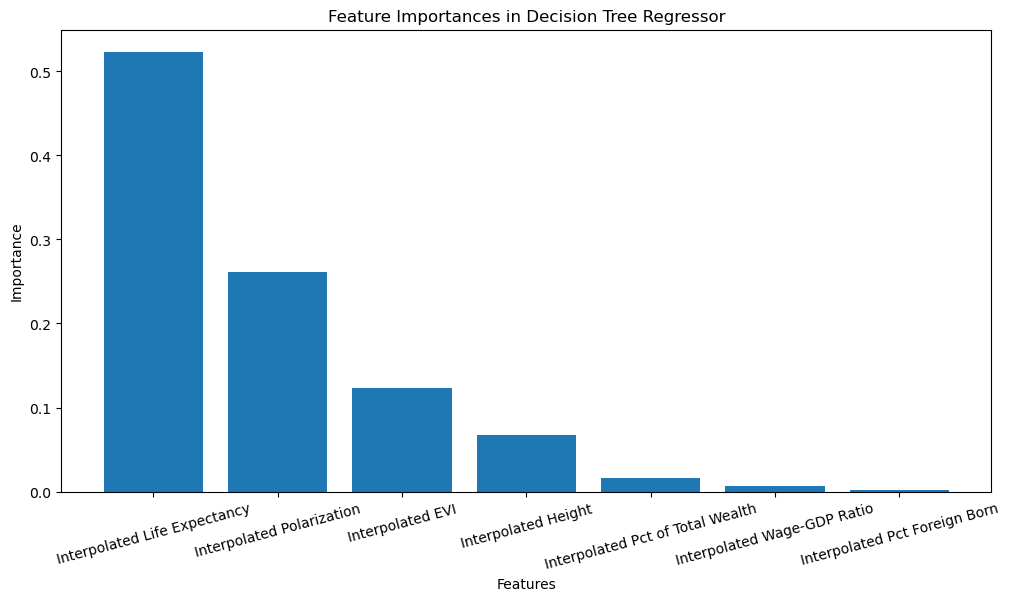

In [589]:
#Plot feature importances
feature_importances = best_tree.feature_importances_
features = X_train.columns
plt.figure(figsize=(12, 6))
indices = np.argsort(feature_importances)[::-1]
plt.bar(range(X_train.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=15)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importances in Decision Tree Regressor')
plt.show()

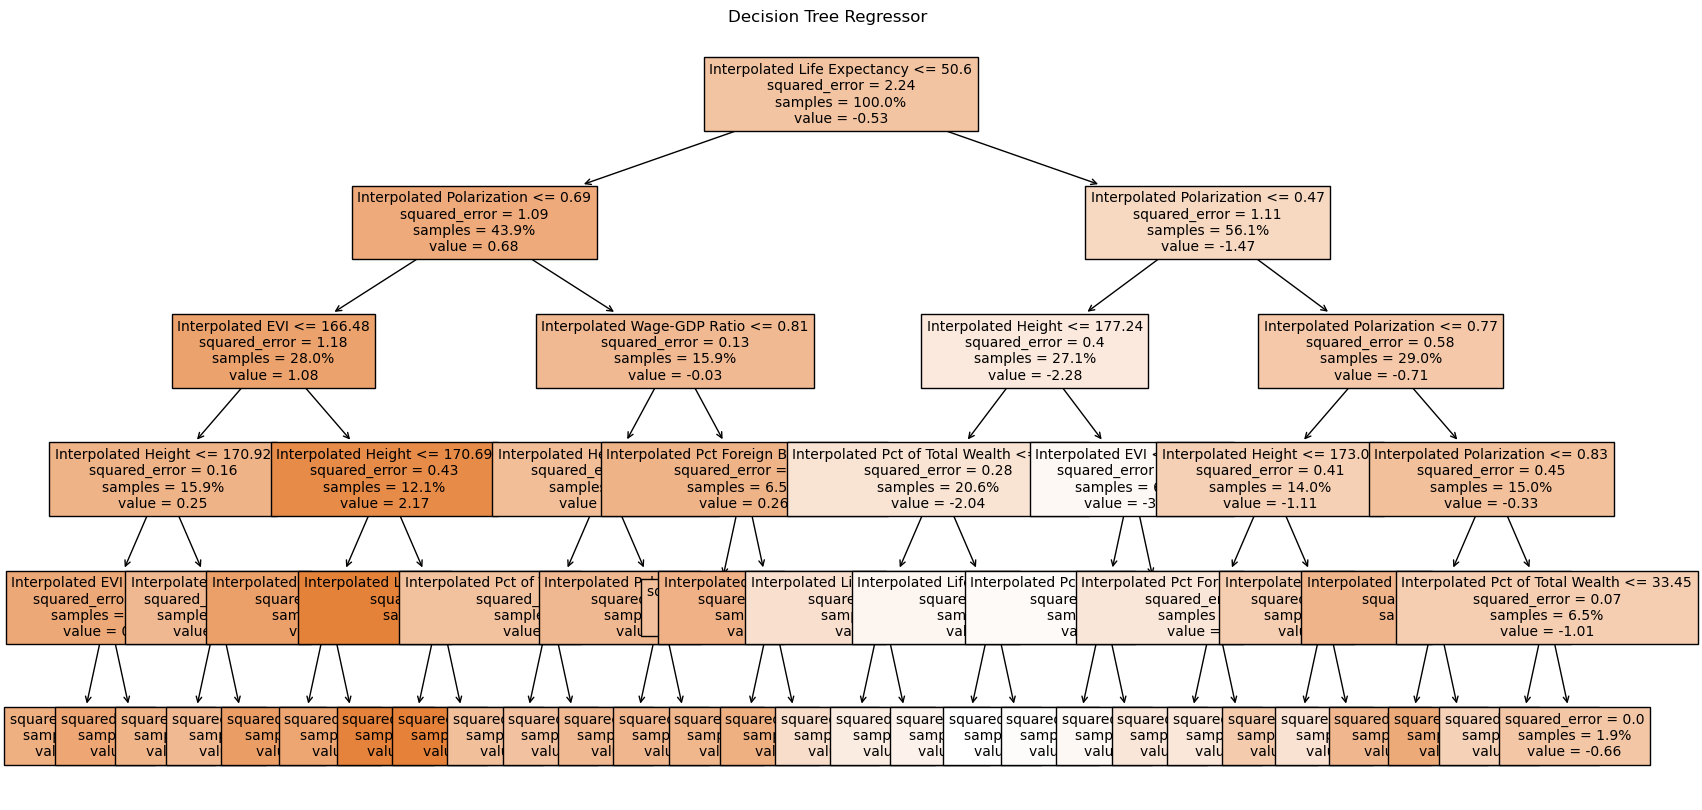

In [590]:
#Plot Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(best_tree, filled=True, feature_names=X_train.columns, fontsize=10, proportion=True, precision=2)
plt.title('Decision Tree Regressor')
plt.show()

## Random Forest Regressor

In [591]:
#Set up random forest regressor and find best parameters
rnd_forest_model = RandomForestRegressor(random_state=42)

rnd_forest_param_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 400, 500],  
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 35, 40],
}

rnd_forest_grid_search = GridSearchCV(estimator=rnd_forest_model, param_grid=rnd_forest_param_grid, cv=10, scoring='neg_mean_squared_error', verbose=1)
rnd_forest_grid_search.fit(X_train, y_train)

#Best parameters and MSE
rnd_forest_best_params = rnd_forest_grid_search.best_params_
rnd_forest_best_mse = -rnd_forest_grid_search.best_score_
print('Best Parameters:', rnd_forest_best_params)
print('Best Train Mean Squared Error (MSE):', rnd_forest_best_mse)

#Evaluate model on test data
best_rnd_forest = RandomForestRegressor(**rnd_forest_best_params, random_state=42)
best_rnd_forest.fit(X_train, y_train)
y_pred = best_rnd_forest.predict(X_test)
rnd_forest_test_mse = mean_squared_error(y_test, y_pred)
rnd_forest_test_mae = mean_absolute_error(y_test, y_pred)
rnd_forest_test_rsquared = r2_score(y_test, y_pred)
print('Test Mean Squared Error (MSE):', rnd_forest_test_mse)
print('Test Mean Absolute Error (MAE):', rnd_forest_test_mae)
print('Test R-squared (R²) Score:', rnd_forest_test_rsquared)

Fitting 10 folds for each of 63 candidates, totalling 630 fits


/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

...

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best Train Mean Squared Error (MSE): 0.2597162631682407
Test Mean Squared Error (MSE): 0.19600478727595105
Test Mean Absolute Error (MAE): 0.33428154322424564
Test R-squared (R²) Score: 0.877647514409549


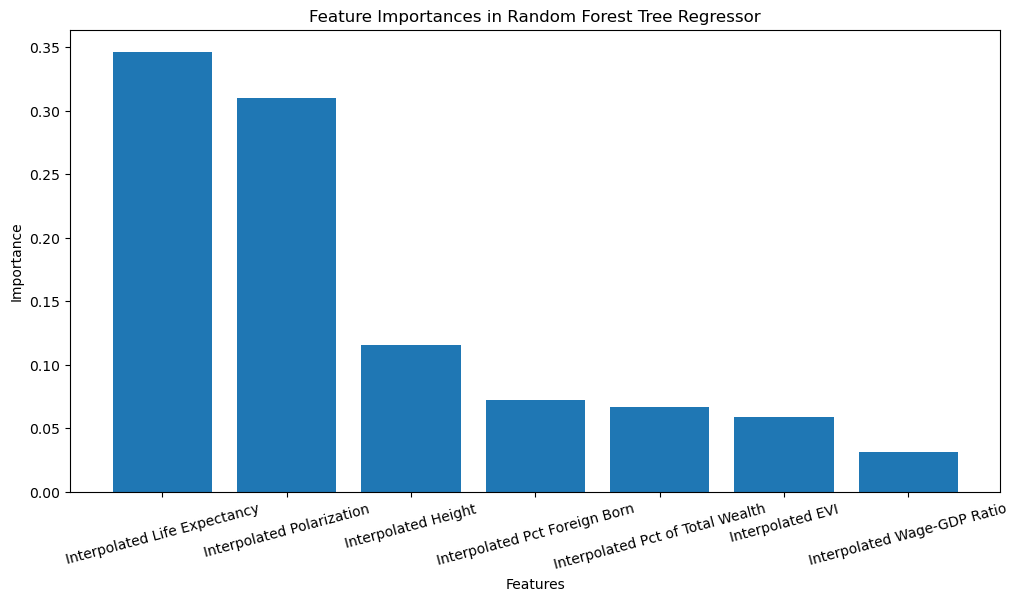

In [592]:
#Plot feature importances
feature_importances = best_rnd_forest.feature_importances_
features = X_train.columns
plt.figure(figsize=(12, 6))
indices = np.argsort(feature_importances)[::-1]
plt.bar(range(X_train.shape[1]), feature_importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=15)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importances in Random Forest Tree Regressor')
plt.show()

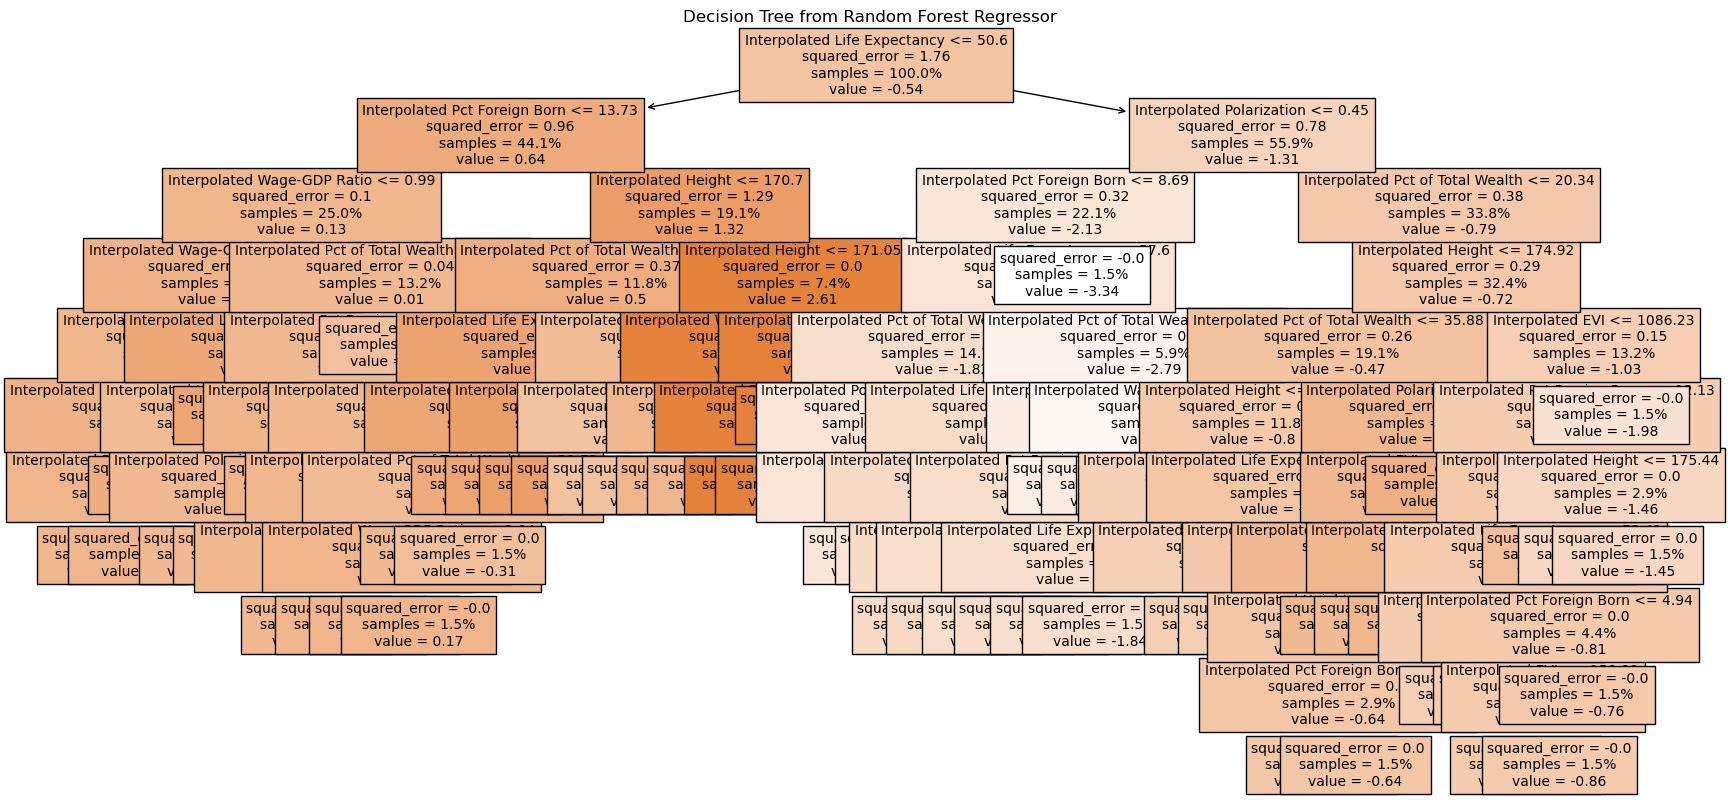

In [593]:
#Plot Random Forest Regressor
plt.figure(figsize=(20, 10))
tree = best_rnd_forest.estimators_[0]
plot_tree(tree, filled=True, feature_names=X_train.columns, fontsize=10, proportion=True, precision=2)
plt.title('Decision Tree from Random Forest Regressor')
plt.show()

In [594]:
data = {'Model Types':['Linear Regression', 'LASSO Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest Regression'],
        'Mean Squared Error (MSE)': [linear_test_mse,lasso_test_mse,ridge_test_mse,tree_test_mse,rnd_forest_test_mse],
        'Mean Absolute Error (MAE)': [linear_test_mae,lasso_test_mae,ridge_test_mae,tree_test_mae,rnd_forest_test_mae],
        'R^2': [linear_test_rsquared,lasso_test_rsquared,ridge_test_rsquared,tree_test_rsquared,rnd_forest_test_rsquared]}
results_1 = pd.DataFrame(data)
results_1

,Model Types,Mean Squared Error (MSE),Mean Absolute Error (MAE),R^2
0,Linear Regression,0.580832,0.642504,0.637426
1,LASSO Regression,0.582617,0.660022,0.636312
2,Ridge Regression,0.582934,0.655326,0.636114
3,Decision Tree,0.390300,0.416022,0.756362
4,Random Forest Regression,0.196005,0.334282,0.877648


## 4. FIND THE BEST DIMENSIONALITY REDUCTION FOR REGRESSION

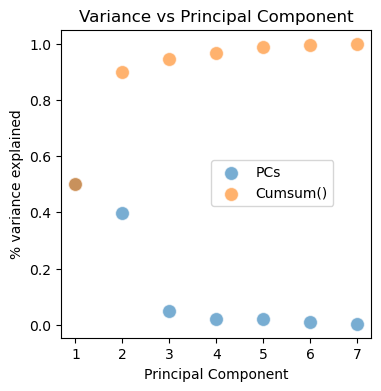

In [595]:
#Choose and scale features 
features = X.columns
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_final[features])
df_final.loc[:, features] = scaled_features

#Perform PCA analysis
N = len(features)
pca_model = PCA(n_components=N)
pca_model.fit(df_final[features])

#Plot variance
plt.figure(figsize=(4,4))
sns.scatterplot(x=range(1,N+1), 
                y=pca_model.explained_variance_ratio_, 
                s=100,
               alpha=0.6)
sns.scatterplot(x=range(1,N+1), 
                y=pca_model.explained_variance_ratio_.cumsum(), 
                s=100, alpha=0.6)
plt.title('Variance vs Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('% variance explained')
plt.legend(['PCs', 'Cumsum()'], bbox_to_anchor=[0.9, 0.6])
plt.show()

In [596]:
#Variance for each principal component
variance_explained = pca_model.explained_variance_ratio_
variance_explained

array([0.49960044, 0.39827747, 0.04809126, 0.02094845, 0.020622  ,
       0.00887788, 0.0035825 ])

In [597]:
#Cumulative variance for each principal component
cumulative_variance_explained = np.cumsum(variance_explained)
cumulative_variance_explained

array([0.49960044, 0.89787791, 0.94596918, 0.96691762, 0.98753962,
       0.9964175 , 1.        ])

In [598]:
#Pca model for 2 components
pca_2_model = PCA(n_components=2) 
pca_2_model.fit(df_final[features])
pcs_df = pca_2_model.transform(df_final[features])
df_final['PC1'] = pcs_df[:,0]
df_final['PC2'] = pcs_df[:,1]
pca_features = ['PC1', 'PC2']

/var/folders/b9/kvwg4mzj5kv0208_l9z2ljsc0000gn/T/ipykernel_20733/799484708.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['PC1'] = pcs_df[:,0]
/var/folders/b9/kvwg4mzj5kv0208_l9z2ljsc0000gn/T/ipykernel_20733/799484708.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['PC2'] = pcs_df[:,1]


In [599]:
#Make new X and Y
pca_X = df_final[pca_features]
X_train_pca, X_test_pca, y_train, y_test = train_test_split(pca_X, y, test_size=0.3, random_state = 42)

## PCA Decision Tree Regressor

In [600]:
#Set up pca decision tree regressor and find best parameters
pca_tree_model = DecisionTreeRegressor(random_state=42)

pca_tree_param_grid = {
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 35, 40],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
}

pca_tree_grid_search = GridSearchCV(estimator=pca_tree_model, param_grid=pca_tree_param_grid, cv=10, scoring='neg_mean_squared_error', verbose=1)
pca_tree_grid_search.fit(X_train_pca, y_train)

#Best parameters and MSE
pca_tree_best_params = pca_tree_grid_search.best_params_
pca_tree_best_mse = -pca_tree_grid_search.best_score_
print('Best Parameters:', pca_tree_best_params)
print('Best Train Mean Squared Error (MSE):', pca_tree_best_mse)

#Evaluate model on test data
pca_best_tree = DecisionTreeRegressor(**pca_tree_best_params, random_state=42)
pca_best_tree.fit(X_train_pca, y_train)
y_pred = pca_best_tree.predict(X_test_pca)
pca_tree_test_mse = mean_squared_error(y_test, y_pred)
pca_tree_test_mae = mean_absolute_error(y_test, y_pred)
pca_tree_test_rsquared = r2_score(y_test, y_pred)
print('Test Mean Squared Error (MSE):', pca_tree_test_mse)
print('Test Mean Absolute Error (MAE):', pca_tree_test_mae)
print('Test R-squared (R²) Score:', pca_tree_test_rsquared)

Fitting 10 folds for each of 63 candidates, totalling 630 fits
Best Parameters: {'ccp_alpha': 0.01, 'max_depth': None}
Best Train Mean Squared Error (MSE): 0.49073573963315537
Test Mean Squared Error (MSE): 0.5753993592082453
Test Mean Absolute Error (MAE): 0.4909650590917161
Test R-squared (R²) Score: 0.6408172331670414


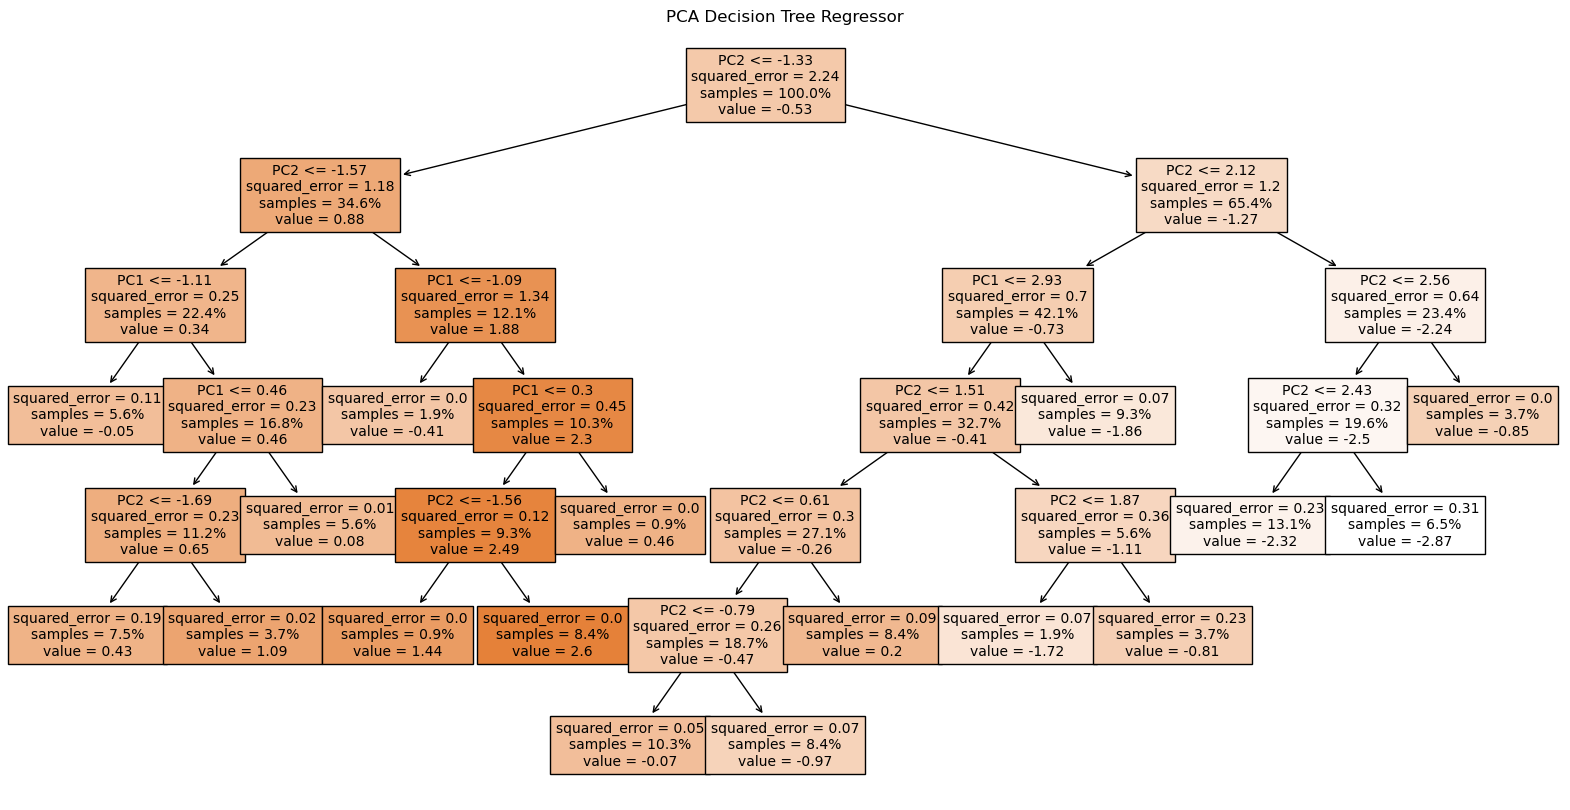

In [601]:
#Plot PCA Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(pca_best_tree, filled=True, feature_names=X_train_pca.columns, fontsize=10, proportion=True, precision=2)
plt.title('PCA Decision Tree Regressor')
plt.show()

## PCA Random Forest Regressor

In [602]:
#Set up pca random forest regressor and find best parameters
pca_rnd_forest_model = RandomForestRegressor(random_state=42)

pca_rnd_forest_param_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 400, 500],  
    'max_depth': [None, 5, 10, 15, 20, 25, 30, 35, 40],
}

pca_rnd_forest_grid_search = GridSearchCV(estimator=rnd_forest_model, param_grid=rnd_forest_param_grid, cv=10, scoring='neg_mean_squared_error', verbose=1)
pca_rnd_forest_grid_search.fit(X_train_pca, y_train)

#Best parameters and MSE
pca_rnd_forest_best_params = pca_rnd_forest_grid_search.best_params_
pca_rnd_forest_best_mse = -pca_rnd_forest_grid_search.best_score_
print('Best Parameters:', pca_rnd_forest_best_params)
print('Best Train Mean Squared Error (MSE):', pca_rnd_forest_best_mse)

#Evaluate model on test data
pca_best_rnd_forest = RandomForestRegressor(**pca_rnd_forest_best_params, random_state=42)
pca_best_rnd_forest.fit(X_train_pca, y_train)
y_pred = pca_best_rnd_forest.predict(X_test_pca)
pca_rnd_forest_test_mse = mean_squared_error(y_test, y_pred)
pca_rnd_forest_test_mae = mean_absolute_error(y_test, y_pred)
pca_rnd_forest_test_rsquared = r2_score(y_test, y_pred)
print('Test Mean Squared Error (MSE):', pca_rnd_forest_test_mse)
print('Test Mean Absolute Error (MAE):', pca_rnd_forest_test_mae)
print('Test R-squared (R²) Score:', pca_rnd_forest_test_rsquared)

Fitting 10 folds for each of 63 candidates, totalling 630 fits


/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

...

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector 

Best Parameters: {'max_depth': None, 'n_estimators': 300}
Best Train Mean Squared Error (MSE): 0.3466256089053606
Test Mean Squared Error (MSE): 0.3777592312018949
Test Mean Absolute Error (MAE): 0.4365524578673419
Test R-squared (R²) Score: 0.7641905509827276


/var/folders/b9/kvwg4mzj5kv0208_l9z2ljsc0000gn/T/ipykernel_20733/3393262055.py:20: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  pca_best_rnd_forest.fit(X_train_pca, y_train)


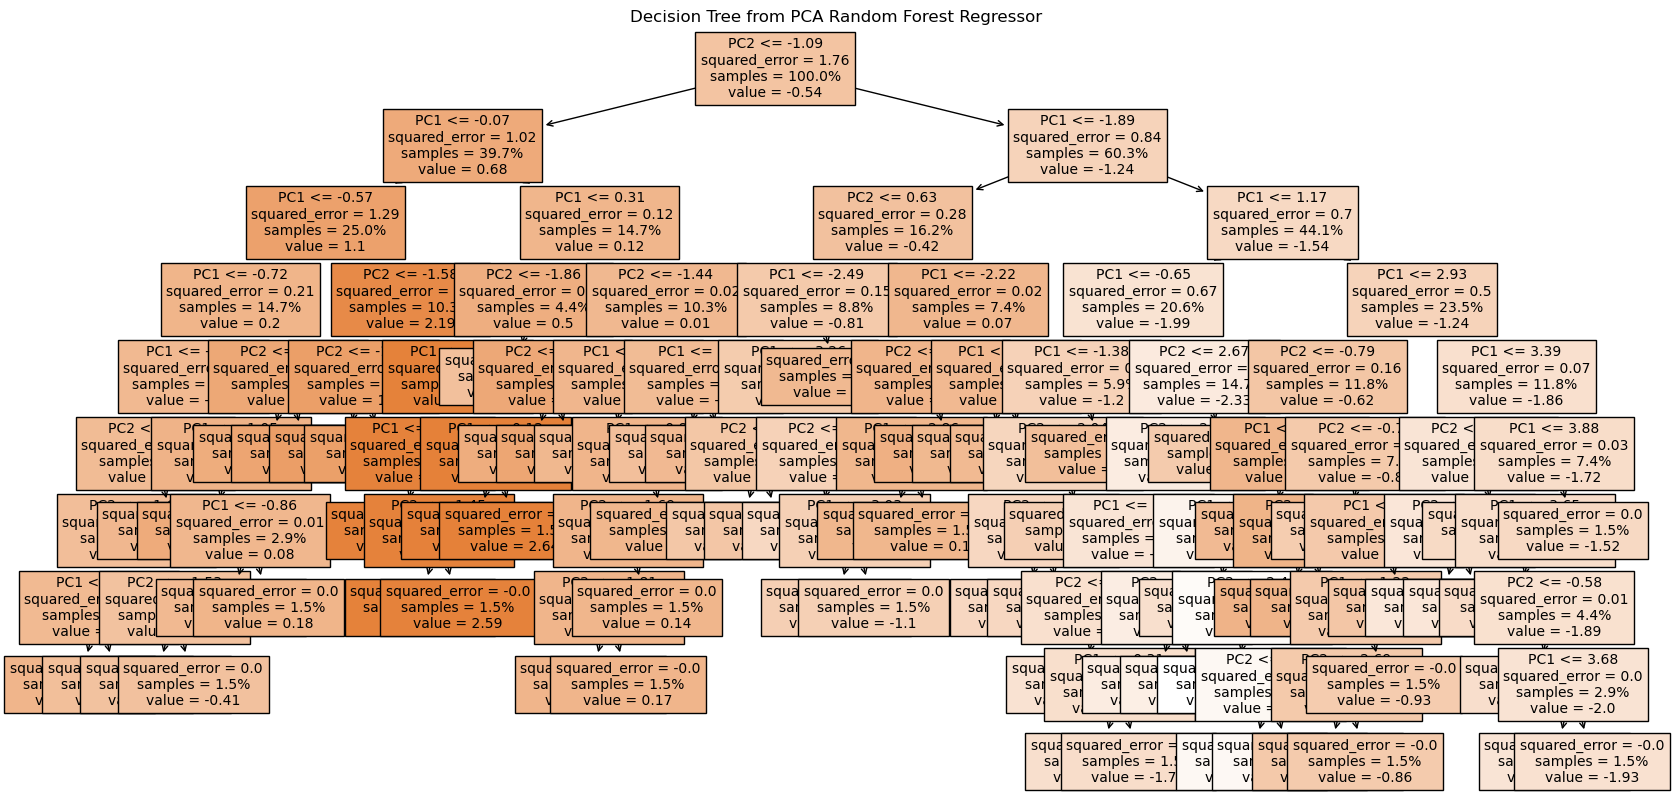

In [603]:
#Plot PCA Random Forest Regressor
plt.figure(figsize=(20, 10))
tree = pca_best_rnd_forest.estimators_[0]
plot_tree(tree, filled=True, feature_names=X_train_pca.columns, fontsize=10, proportion=True, precision=2)
plt.title('Decision Tree from PCA Random Forest Regressor')
plt.show()

# 5. FIND THE BEST DIMENSIONALITY REDUCTION FOR UNSUPERVISED CLASSIFICATION

## PCA Kmeans Classifier

In [604]:
#Unsupervised pca model for 2 components
unsupervised_pca_2_model = PCA(n_components=2)
features.append(pd.Index(['Political Instability Index']))
unsupervised_pca_2_model.fit(df_final[features])
unsupervised_pcs_df = unsupervised_pca_2_model.transform(df_final[features])
df_final['PC1_unsupervised'] = unsupervised_pcs_df[:,0]
df_final['PC2_unsupervised'] = unsupervised_pcs_df[:,1]
unsupervised_pca_features = ['PC1_unsupervised', 'PC2_unsupervised']

/var/folders/b9/kvwg4mzj5kv0208_l9z2ljsc0000gn/T/ipykernel_20733/3160046425.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['PC1_unsupervised'] = unsupervised_pcs_df[:,0]
/var/folders/b9/kvwg4mzj5kv0208_l9z2ljsc0000gn/T/ipykernel_20733/3160046425.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['PC2_unsupervised'] = unsupervised_pcs_df[:,1]


Automatically found elbow at 4 clusters.


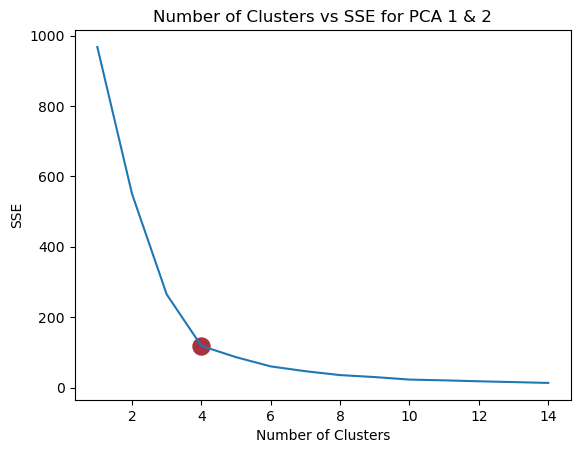

In [605]:
#Plot and find the best number of clusters
kmeans_kwargs = {'init': 'random', 'n_init': 10, 
                 'max_iter': 300}
sse = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(df_final[unsupervised_pca_features])
    sse.append(kmeans.inertia_)
    
kl = KneeLocator(range(1, 15), sse, curve='convex', direction='decreasing')
print('Automatically found elbow at %d clusters.'%kl.elbow)

plt.plot(range(1, 15), sse)
plt.title('Number of Clusters vs SSE for PCA 1 & 2')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')  
plt.scatter(kl.elbow, kl.elbow_y, s=150, c='#a8323e');

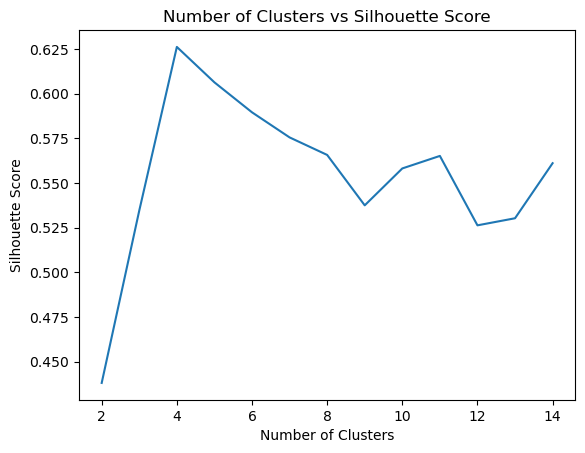

In [606]:
#Plot and find the silhouette score to clusters
silhouette_coefficients = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(df_final[unsupervised_pca_features])
    score = silhouette_score(df_final[unsupervised_pca_features].values, kmeans.labels_)
    silhouette_coefficients.append(score)
    
plt.plot(range(2, 15), silhouette_coefficients)
plt.title('Number of Clusters vs Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score');

# 6. BRIEFLY EXPLORE THE CLUSTERS OF INSTABILITY SCORES

/var/folders/b9/kvwg4mzj5kv0208_l9z2ljsc0000gn/T/ipykernel_20733/3180438589.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['Cluster'] = kmeans.labels_


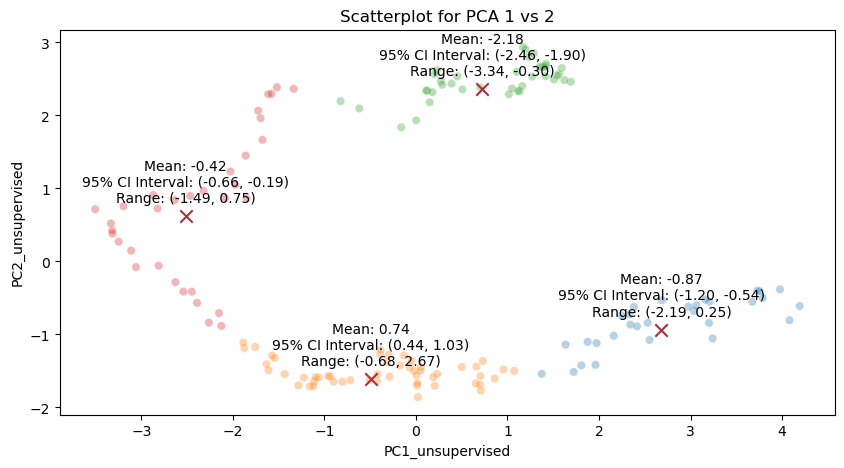

Silhouette score: 0.6261935690234652


In [607]:
#Create a scatterplot with best number of clusters
n_clusters = 4
kmeans = KMeans(init='random', n_clusters=n_clusters,
                n_init=10, max_iter=300)
kmeans.fit(df_final[unsupervised_pca_features])

#Find average, range, and CI
df_final['Cluster'] = kmeans.labels_
average_instability = df_final.groupby('Cluster')['Political Instability Index'].mean
sample_sizes = df_final.groupby('Cluster').size()
cluster_means = df_final.groupby('Cluster')['Political Instability Index'].mean()
standard_errors = df_final.groupby('Cluster')['Political Instability Index'].std() / np.sqrt(sample_sizes)
t_score = t.ppf(0.975, sample_sizes - 1) 
margin_of_error = t_score * standard_errors
lower_bound = cluster_means - margin_of_error
upper_bound = cluster_means + margin_of_error
min_values = df_final.groupby('Cluster')['Political Instability Index'].min()
max_values = df_final.groupby('Cluster')['Political Instability Index'].max()

fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.scatterplot(ax=ax, 
                x=df_final[unsupervised_pca_features[0]]+np.random.rand(len(df_final))*0.2, 
                y=df_final[unsupervised_pca_features[1]]+np.random.rand(len(df_final))*0.2,
                hue=kmeans.labels_, 
                palette=sns.color_palette('tab10', 
                                          n_colors=n_clusters),
                legend=None, alpha = 0.33)

for n, [pc1, pc2] in enumerate(kmeans.cluster_centers_):
    ax.scatter(pc1, pc2, s=80, marker='x', c='#a8323e')
    ax.annotate(f'Mean: {cluster_means[n]:.2f}\n95% CI Interval: ({lower_bound[n]:.2f}, {upper_bound[n]:.2f})\nRange: ({min_values[n]:.2f}, {max_values[n]:.2f})', (pc1, pc2), textcoords='offset points', xytext=(0,10), ha='center')
plt.title('Scatterplot for PCA 1 vs 2')
plt.show()

silhouette_score = silhouette_score(df_final[unsupervised_pca_features].values, kmeans.labels_)
print('Silhouette score:', silhouette_score)

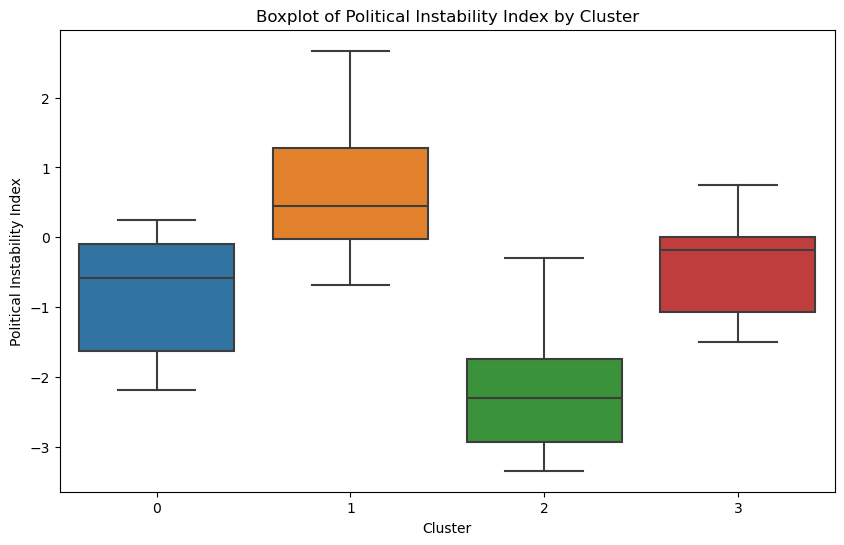

In [608]:
#Create a boxplot of political instability index by cluster
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='Cluster', y='Political Instability Index', palette='tab10')
plt.title('Boxplot of Political Instability Index by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Political Instability Index')
plt.show()